# Customer Segmentation for a Luxury Clothing Brand

## 1. Business Problem

A luxury clothing brand wants to optimize its marketing campaigns by:
- identifying distinct customer segments
- tailoring messaging and budget allocation to each segment
- improving campaign ROI

This analysis aims to identify actionable customer segments using behavioral and demographic data.


## 2. Data Exploration and Preparation


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
data = pd.read_csv("Clothing_Customers.csv")
data.head(5)

,income,age,days_since_purchase,annual_spend
0,37453,48,504,4441
1,50775,50,566,4239
2,71047,41,326,5834
3,52239,52,259,5456
4,112343,27,279,1749


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   income               1000 non-null   int64
 1   age                  1000 non-null   int64
 2   days_since_purchase  1000 non-null   int64
 3   annual_spend         1000 non-null   int64
dtypes: int64(4)
memory usage: 31.4 KB


In [7]:
data.describe().round(2)

,income,age,days_since_purchase,annual_spend
count,1000.00,1000.00,1000.00,1000.00
mean,72617.90,41.44,419.56,4337.22
std,39511.97,10.85,112.15,1667.29
min,0.00,18.00,141.00,243.00
25%,39635.50,31.00,310.00,2747.50
50%,60204.50,45.00,455.50,4879.50
75%,111329.25,50.00,510.00,5681.25
max,171935.00,66.00,636.00,7572.00


In [8]:
data.isna().sum()

income                 0
age                    0
days_since_purchase    0
annual_spend           0
dtype: int64

In [9]:
data_scaled = data.copy()
cols_to_scale = data.columns

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

data_scaled[cols_to_scale] = scaler.fit_transform(data_scaled[cols_to_scale])

## 3. Data Visualization Using PCA

The dataset contains four standardized features, making direct visualization difficult.

PCA is used to project the data into two dimensions (PC1 and PC2) for visualization purposes. The clustering itself will be performed using all four standardized features to preserve the information contained in the original dataset.

In [11]:
from sklearn import decomposition
pca = decomposition.PCA(n_components=2)
pca_res = pca.fit_transform(data_scaled[cols_to_scale])

data_scaled['pc1'] = pca_res[:,0]
data_scaled['pc2'] = pca_res[:,1]

In [12]:
explained_variance = pca.explained_variance_ratio_

print(f"PC1 explained variance: {explained_variance[0]:.1%}")
print(f"PC2 explained variance: {explained_variance[1]:.1%}")
print(f"Total explained variance: {explained_variance.sum():.1%}")

PC1 explained variance: 47.5%
PC2 explained variance: 26.2%
Total explained variance: 73.6%


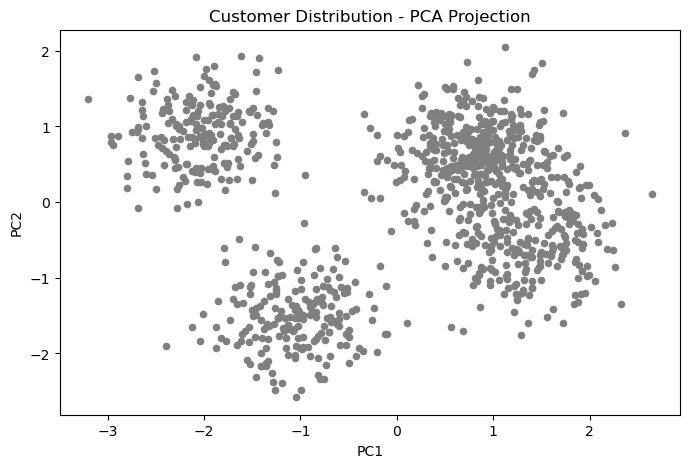

In [13]:
data_scaled.plot.scatter(
    x="pc1",
    y="pc2",
    color="gray",
    figsize=(8, 5),
    title="Customer Distribution - PCA Projection"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

### Why Clustering?

Since no labeled customer segments exist, we use unsupervised learning.
Clustering allows us to:
- discover naturally occurring customer groups
- design differentiated marketing strategies
- avoid one-size-fits-all campaigns


## 4. Exploring Different Numbers of Clusters


In [16]:
from sklearn.cluster import KMeans

# K-means will use all four standardized features
X = data_scaled[cols_to_scale]

markers = ['x', '*', '.', '|', '_', '1', '2']

C:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Le fichier spécifié est introuvable
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\User\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(execut

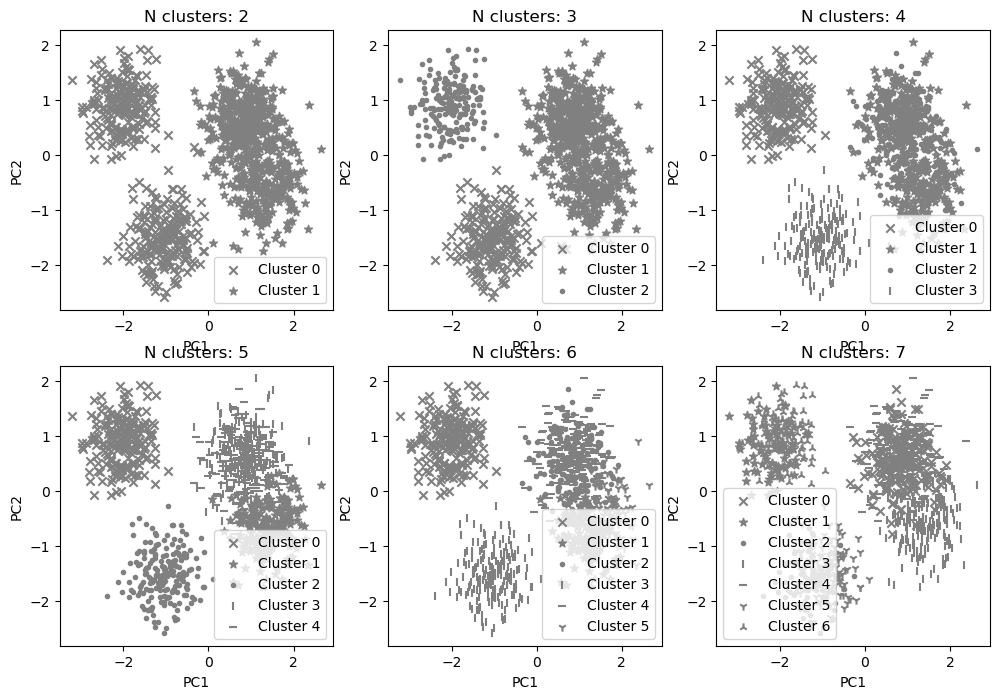

In [17]:
plt.figure(figsize=[12, 8])

for n in range(2,8):
    model = KMeans(n_clusters=n, random_state=42, n_init=10)
    data_scaled['Cluster'] = model.fit_predict(X)
    
    plt.subplot(2,3, n-1)
    for clust in range(n):
        temp = data_scaled[data_scaled.Cluster == clust]
        plt.scatter(temp.pc1, temp.pc2, marker=markers[clust], label="Cluster "+str(clust), color='gray')
        plt.title("N clusters: "+str(n))
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.legend()

plt.show()

The PCA projection provides a useful visual representation of the different clustering solutions. However, because PCA only shows a two-dimensional projection of the original four-dimensional feature space, visual inspection alone should not be used to select the optimal number of clusters.

We therefore complement this visualization with quantitative clustering metrics.

## 5. Selecting the Optimal Number of Clusters

In [20]:
inertia_scores = []
for K in range (2, 11):
    inertia = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X).inertia_
    inertia_scores.append(inertia)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows wi

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows wi

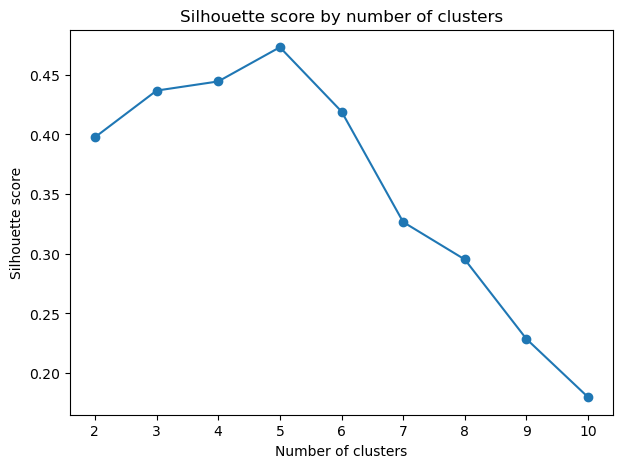

In [21]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = model.fit_predict(X)
    score = silhouette_score(X, cluster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(7, 5))
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.title("Silhouette score by number of clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.show()

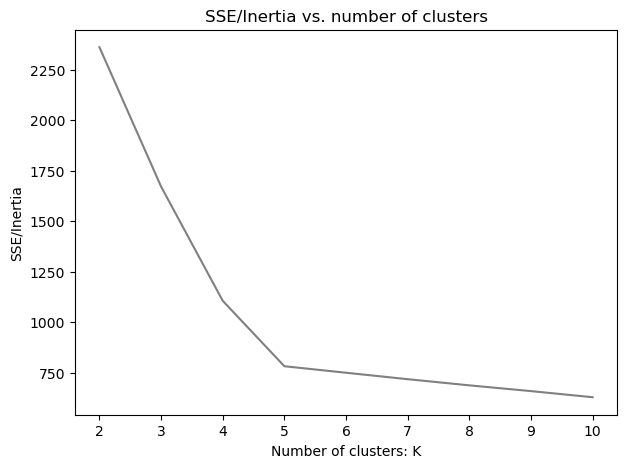

In [22]:
plt.figure(figsize=[7,5])
plt.plot(range(2,11), inertia_scores, color='gray')
plt.title("SSE/Inertia vs. number of clusters")
plt.xlabel("Number of clusters: K")
plt.ylabel("SSE/Inertia")
plt.show()

Both evaluation methods suggest that **5 clusters** provide an appropriate segmentation.

The silhouette score reaches its maximum at K=5, indicating the best balance between cluster cohesion and separation among the tested solutions.

The elbow method leads to a similar conclusion: inertia decreases substantially from K=2 to K=5, while additional clusters provide relatively limited improvements.

Based on these results, **K=5 is selected for the final customer segmentation**.

In [24]:
final_model = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

data["Cluster"] = final_model.fit_predict(X)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [25]:
cluster_profile = (
    data.groupby("Cluster")[cols_to_scale]
        .mean()
        .round(2)
)

cluster_profile

,income,age,days_since_purchase,annual_spend
Cluster,,,,
0,116310.54,29.29,294.13,2501.73
1,43101.81,50.05,505.22,5568.37
2,42643.61,30.04,500.57,2501.76
3,115626.49,48.91,498.50,5540.82
4,44331.05,48.94,297.47,5574.00


In [26]:
cluster_share = (
    data["Cluster"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(1)
)

cluster_share

Cluster
0    19.9
1    19.7
2    20.1
3    20.4
4    19.9
Name: proportion, dtype: float64

## 6. Customer Segment Analysis

The clustering reveals five distinct customer profiles, each representing approximately 20% of the customer base.

The segments differ substantially across income, age, purchasing recency and annual spending, allowing the statistical clusters to be translated into meaningful customer profiles.

### 6.1 Visualizing Customer Segment Profiles

To better understand how the five customer segments differ, we compare their average characteristics across the four variables used for clustering.

In [29]:
profile_scaled = (
    data_scaled
    .assign(Cluster=data["Cluster"])
    .groupby("Cluster")[cols_to_scale]
    .mean()
)

profile_scaled

,income,age,days_since_purchase,annual_spend
Cluster,,,,
0,1.106361,-1.120938,-1.119041,-1.101434
1,-0.747390,0.794036,0.764125,0.738784
2,-0.758993,-1.051906,0.722632,-1.101415
3,1.089040,0.688516,0.704191,0.722251
4,-0.716264,0.691545,-1.089184,0.742162


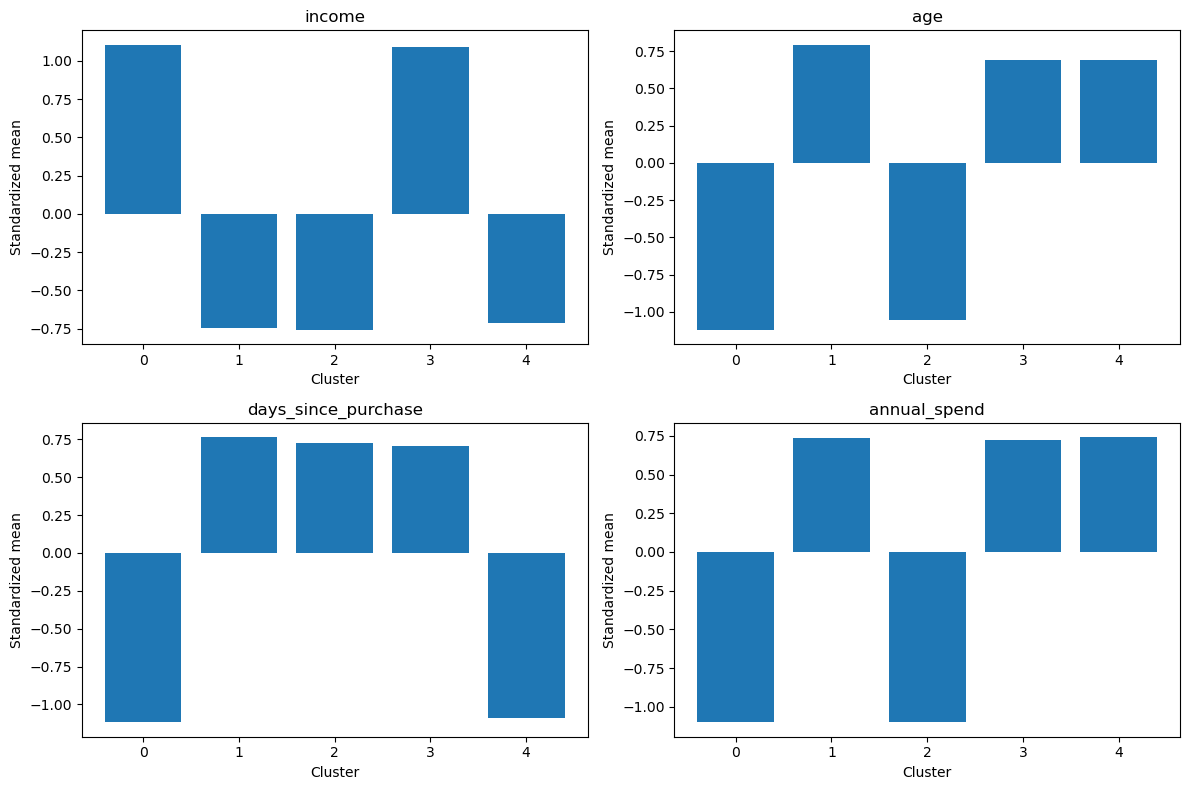

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), cols_to_scale):
    ax.bar(
        profile_scaled.index.astype(str),
        profile_scaled[feature]
    )
    ax.set_title(feature)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Standardized mean")

plt.tight_layout()
plt.show()

### 6.2 Final Segmentation Visualization

The final segmentation is projected onto the first two principal components for visualization. The clusters were identified using all four standardized features; PCA is used here only to provide a two-dimensional representation of the resulting segmentation.

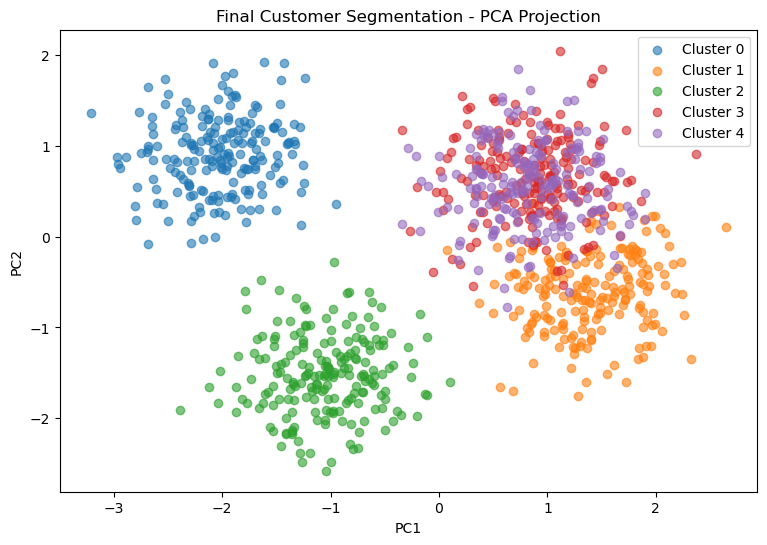

In [32]:
plt.figure(figsize=(9, 6))

for cluster in sorted(data["Cluster"].unique()):
    mask = data["Cluster"] == cluster
    
    plt.scatter(
        data_scaled.loc[mask, "pc1"],
        data_scaled.loc[mask, "pc2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Final Customer Segmentation - PCA Projection")
plt.legend()
plt.show()

In [33]:
cluster_names = {
    0: "Young High-Income Low Spenders",
    1: "Mature High Spenders - Inactive",
    2: "Young Low-Value Inactive Customers",
    3: "High-Income High-Value Customers - Inactive",
    4: "Active High Spenders"
}

data["Segment"] = data["Cluster"].map(cluster_names)

### 6.3 Segment Profiles

**Young High-Income Low Spenders (Cluster 0)**  
Young customers with the highest average income, but relatively low annual spending. They have purchased more recently than most other segments, suggesting an opportunity to increase their engagement and share of wallet.

**Mature High Spenders - Inactive (Cluster 1)**  
Older customers with moderate incomes but high annual spending. Their relatively long time since last purchase suggests that they may represent valuable customers at risk of disengagement.

**Young Low-Value Inactive Customers (Cluster 2)**  
Young customers with moderate incomes, low annual spending and a relatively long time since their last purchase. This segment currently represents comparatively low customer value.

**High-Income High-Value Customers - Inactive (Cluster 3)**  
Older, high-income customers with high annual spending. Despite their strong customer value, their relatively long time since last purchase suggests an opportunity for reactivation.

**Active High Spenders (Cluster 4)**  
Older customers with moderate incomes but high annual spending and relatively recent purchases. They represent highly engaged, valuable customers who could be targeted with retention and loyalty initiatives.

## 7. Marketing Recommendations

The five customer segments suggest different marketing priorities.

### Young High-Income Low Spenders
These customers have high purchasing power and relatively recent activity, but their annual spending remains low.

**Potential strategy:** Increase share of wallet through personalized product recommendations, cross-selling and targeted discovery of higher-value products.

### Mature High Spenders - Inactive
These customers historically spend relatively large amounts but have not purchased recently.

**Potential strategy:** Run reactivation campaigns using personalized offers, reminders or communication highlighting new collections.

### Young Low-Value Inactive Customers
These customers combine relatively low spending with low recent engagement.

**Potential strategy:** Use lower-cost automated re-engagement campaigns. Given their comparatively low current value, expensive retention initiatives may be less appropriate.

### High-Income High-Value Customers - Inactive
These customers combine high income with high historical spending but have not purchased recently.

**Potential strategy:** Prioritize them for reactivation through personalized communication, exclusive offers or premium customer experiences.

### Active High Spenders
These customers combine high annual spending with recent purchasing activity.

**Potential strategy:** Focus on retention through loyalty programs, early access to new collections, personalized recommendations and exclusive benefits.

## 8. Conclusion

This analysis identified five distinct customer segments based on income, age, purchase recency and annual spending.

Rather than relying solely on visual inspection, the number of clusters was evaluated using both the elbow method and silhouette score. Both approaches supported a five-cluster solution.

The resulting segmentation highlights meaningful differences in customer value and engagement. In particular, the analysis distinguishes active high-value customers from valuable but inactive customers, as well as younger customers with different spending potential.

These segments could be used as a basis for differentiated marketing strategies, including retention, reactivation and cross-selling initiatives.

### Limitations

Customer segmentation is based on only four variables and provides a descriptive view of customer behavior. Additional information such as purchase frequency, product preferences, acquisition channel or campaign response could improve the segmentation and enable more precise targeting.

The proposed marketing actions should therefore be considered hypotheses to test rather than demonstrated causal effects.